# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot,quarter_plot,plot_acf,plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Load Data

In [4]:
df=pd.read_csv("/content/airmiles.csv",index_col='Date',parse_dates=True,dayfirst=True)
df.head()

,airmiles
Date,
1996-01-01,30983174
1996-02-01,32147663
1996-03-01,38342975
1996-04-01,35969113
1996-05-01,36474391


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 113 entries, 1996-01-01 to 2005-05-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   airmiles  113 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB


In [6]:
df.index

DatetimeIndex(['1996-01-01', '1996-02-01', '1996-03-01', '1996-04-01',
               '1996-05-01', '1996-06-01', '1996-07-01', '1996-08-01',
               '1996-09-01', '1996-10-01',
               ...
               '2004-08-01', '2004-09-01', '2004-10-01', '2004-11-01',
               '2004-12-01', '2005-01-01', '2005-02-01', '2005-03-01',
               '2005-04-01', '2005-05-01'],
              dtype='datetime64[ns]', name='Date', length=113, freq=None)

In [7]:
df=df.asfreq("MS")
df.index

DatetimeIndex(['1996-01-01', '1996-02-01', '1996-03-01', '1996-04-01',
               '1996-05-01', '1996-06-01', '1996-07-01', '1996-08-01',
               '1996-09-01', '1996-10-01',
               ...
               '2004-08-01', '2004-09-01', '2004-10-01', '2004-11-01',
               '2004-12-01', '2005-01-01', '2005-02-01', '2005-03-01',
               '2005-04-01', '2005-05-01'],
              dtype='datetime64[ns]', name='Date', length=113, freq='MS')

In [8]:
df.head()

,airmiles
Date,
1996-01-01,30983174
1996-02-01,32147663
1996-03-01,38342975
1996-04-01,35969113
1996-05-01,36474391


In [11]:
df=df.rename(columns={'airmiles':'y'})
df.head()

,y
Date,
1996-01-01,30983174
1996-02-01,32147663
1996-03-01,38342975
1996-04-01,35969113
1996-05-01,36474391


#EDA

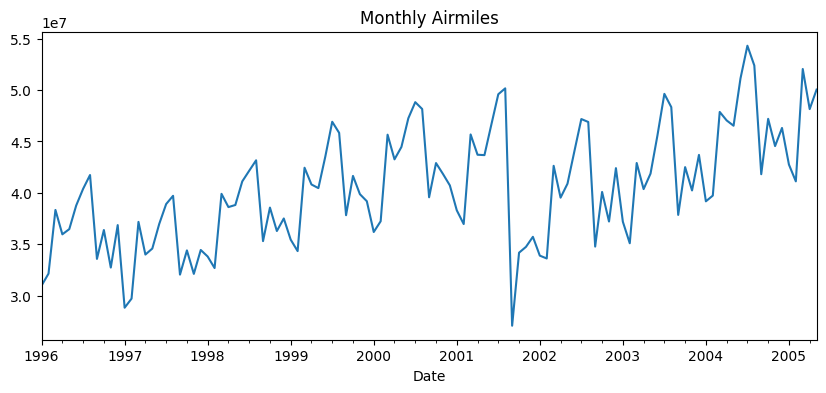

In [13]:
plt.figure(figsize=(10,4))
df['y'].plot(title="Monthly Airmiles")
plt.show()

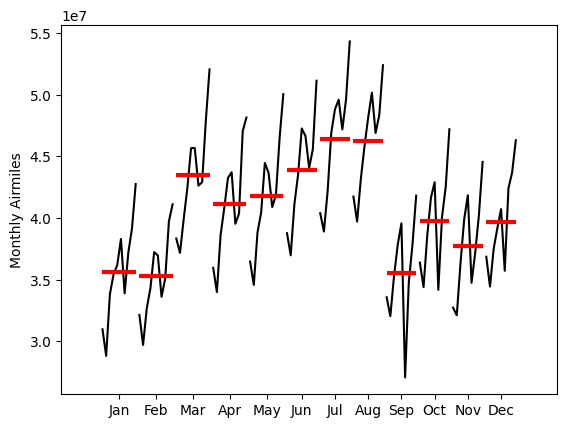

In [14]:
month_plot(df['y'],
           ylabel='Monthly Airmiles')
plt.show()

- Seasonal Pattern: For instance, July and August have the highest averages (red bars), while February and September have some of the lowest. This confirms a strong seasonal effect in the air travel industry.

- Within-Month Trends: In almost every month here, the black line generally trends upward, indicating that even after accounting for seasonality, there is an overall increasing trend in airmiles over time.


---

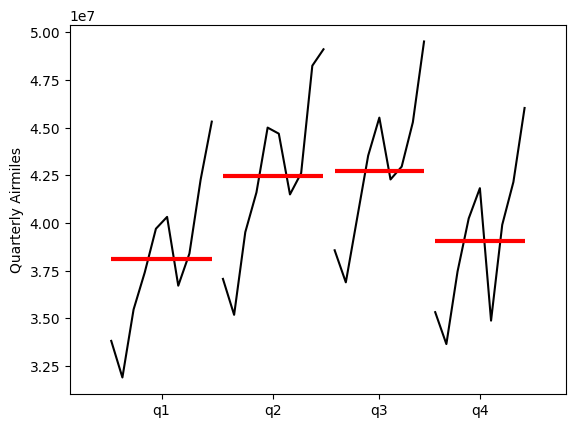

In [16]:
quarter_plot(df['y'].resample('QE').mean(),
           ylabel='Quarterly Airmiles')
plt.show()

<Figure size 1000x500 with 0 Axes>

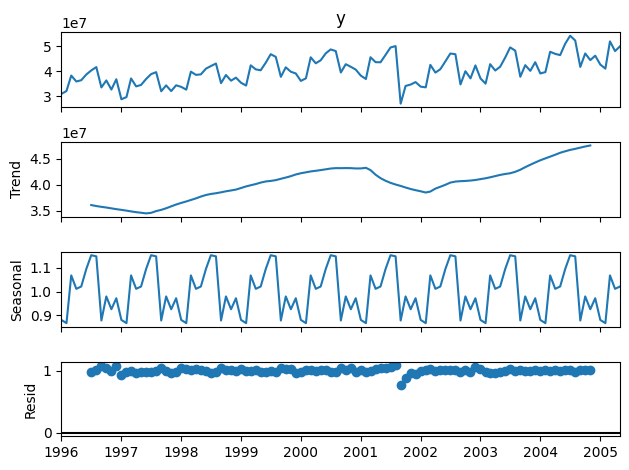

In [18]:
decomposition=seasonal_decompose(df['y'],
                                 model='mul',
                                 period=12)
plt.figure(figsize=(10,5))
decomposition.plot()
plt.show()

<Figure size 1000x500 with 0 Axes>

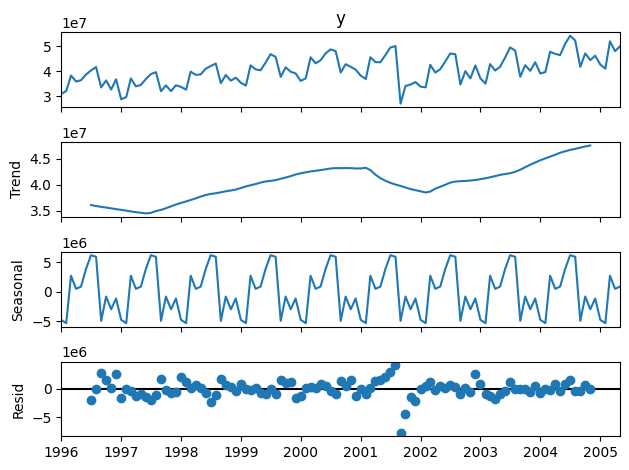

In [19]:
decomposition=seasonal_decompose(df['y'],
                                 model='add',
                                 period=12)
plt.figure(figsize=(10,5))
decomposition.plot()
plt.show()

<Figure size 1000x500 with 0 Axes>

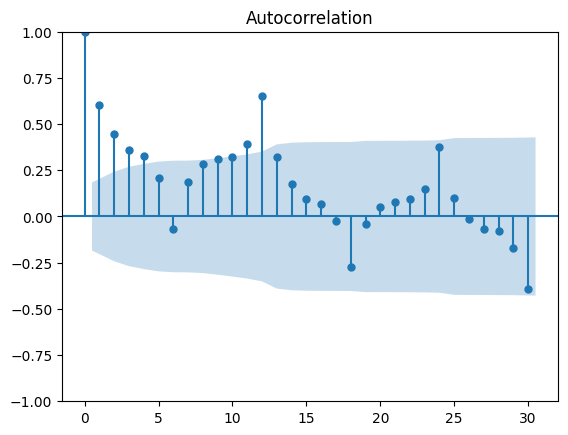

In [20]:
plt.figure(figsize=(10,5))
plot_acf(df['y'],lags=30)
plt.show()

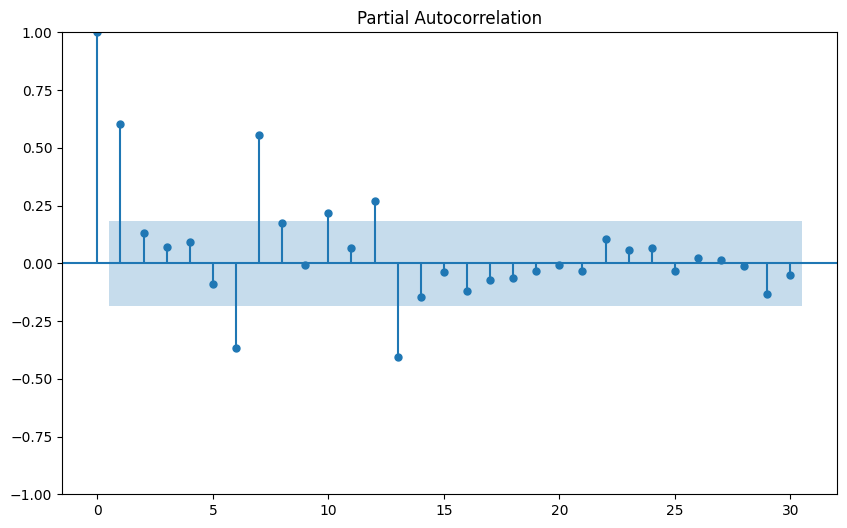

In [21]:
fig,ax=plt.subplots(figsize=(10,6))
plot_pacf(df['y'],lags=30,ax=ax)
plt.show()

# Holt-Winters

In [23]:
df.shape

(113, 1)

In [22]:
train, test = df.iloc[:-12,:], df.iloc[-12:, :]
test.shape,train.shape

((12, 1), (101, 1))

In [33]:
model=ExponentialSmoothing(train,
                           trend='mul',
                           seasonal='mul',
                           seasonal_periods=12).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [34]:
predictions=model.forecast(steps=len(test)).rename('Holt-winters')
predictions

,Holt-winters
2004-06-01,5.008194e+07
2004-07-01,5.296881e+07
2004-08-01,5.297759e+07
2004-09-01,4.026247e+07
2004-10-01,4.514114e+07
2004-11-01,4.288744e+07
2004-12-01,4.506049e+07
2005-01-01,4.099020e+07
2005-02-01,4.067544e+07
2005-03-01,4.995165e+07


In [35]:
def model_plot_acc(train,test,predictions,chart_title):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='Train')
  plt.plot(test,label='Test')
  plt.plot(predictions,label='Forecast')
  plt.title(f"Train ,Test and Predictions With {chart_title}")
  plt.legend()
  plt.show()


  mae=mean_absolute_error(test,predictions)
  rmse=np.sqrt(mean_squared_error(test,predictions))
  mape=mean_absolute_percentage_error(test,predictions)

  print(f"The MAE is {mae:.2f}")
  print(f"The RMSE is {rmse:.2f}")
  print(f"The MAPE is {mape:.2f}%")

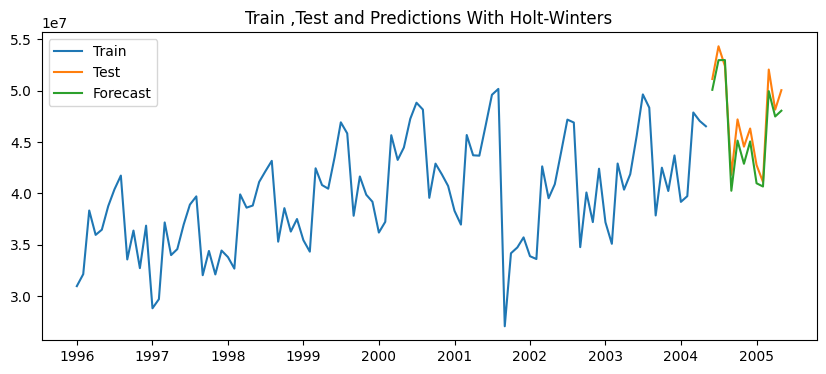

The MAE is 1375680.30
The RMSE is 1485759.69
The MAPE is 0.03%


In [36]:
model_plot_acc(train,test,predictions,'Holt-Winters')

# Forecasting Future

In [37]:
model = ExponentialSmoothing(df['y'],
                             trend = 'mul',
                             seasonal = 'mul',
                             seasonal_periods = 12).fit()

# Forecast future values for the next 12 steps (months in this case)
predictions = model.forecast(steps = 12).rename("Holt-Winters")
predictions

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Holt-Winters
2005-06-01,5.333951e+07
2005-07-01,5.645173e+07
2005-08-01,5.616240e+07
2005-09-01,4.298747e+07
2005-10-01,4.825186e+07
2005-11-01,4.579832e+07
2005-12-01,4.804127e+07
2006-01-01,4.379651e+07
2006-02-01,4.327063e+07
2006-03-01,5.336319e+07


In [38]:
def plot_future_predictions(y,predictions,chart_title):
  plt.figure(figsize=(10,4))
  plt.plot(y,label='Y')
  plt.plot(predictions,label='Forecast')
  plt.title(f"Y and Predictions With {chart_title}")
  plt.legend()
  plt.show()

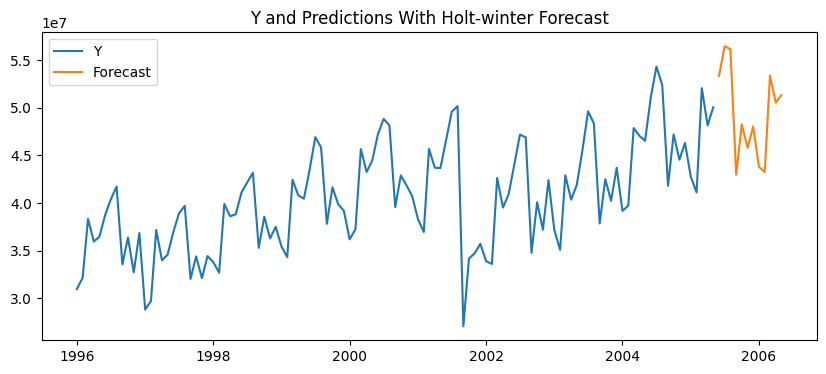

In [39]:
plot_future_predictions(df['y'],predictions,'Holt-winter Forecast')